# House Price Prediction using Linear Regression

**Hands-On Lab**

In this lab you will build, evaluate, and deploy a linear regression model that predicts
house prices from structural and location features. You will practice:

- Exploratory Data Analysis (EDA)
- Simple & Multiple Linear Regression
- Feature Scaling
- Feature Engineering
- Polynomial Regression
- Model Evaluation & Persistence

> This lab assumes you already understand the theory of Supervised Learning, Linear
> Regression, Cost Function, Gradient Descent, Vectorization, Feature Scaling, Feature
> Engineering, and Polynomial Regression. We focus here on **implementation**.

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Load Dataset

In [2]:
df = pd.read_csv("house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (1000, 8)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,1.108237e+06


## 4. Quick Data Quality Check

In [6]:
print("Missing values per column:")
print(df.isna().sum())
print()
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Data types:")
print(df.dtypes)

Missing values per column:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Duplicate rows: 0

Data types:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object


**Observation:** The dataset has no missing values and no duplicate rows, so no
imputation or de-duplication is required. All columns already have numeric dtypes, so no
type conversion is needed before modeling.

## 5. Exploratory Data Analysis (EDA)

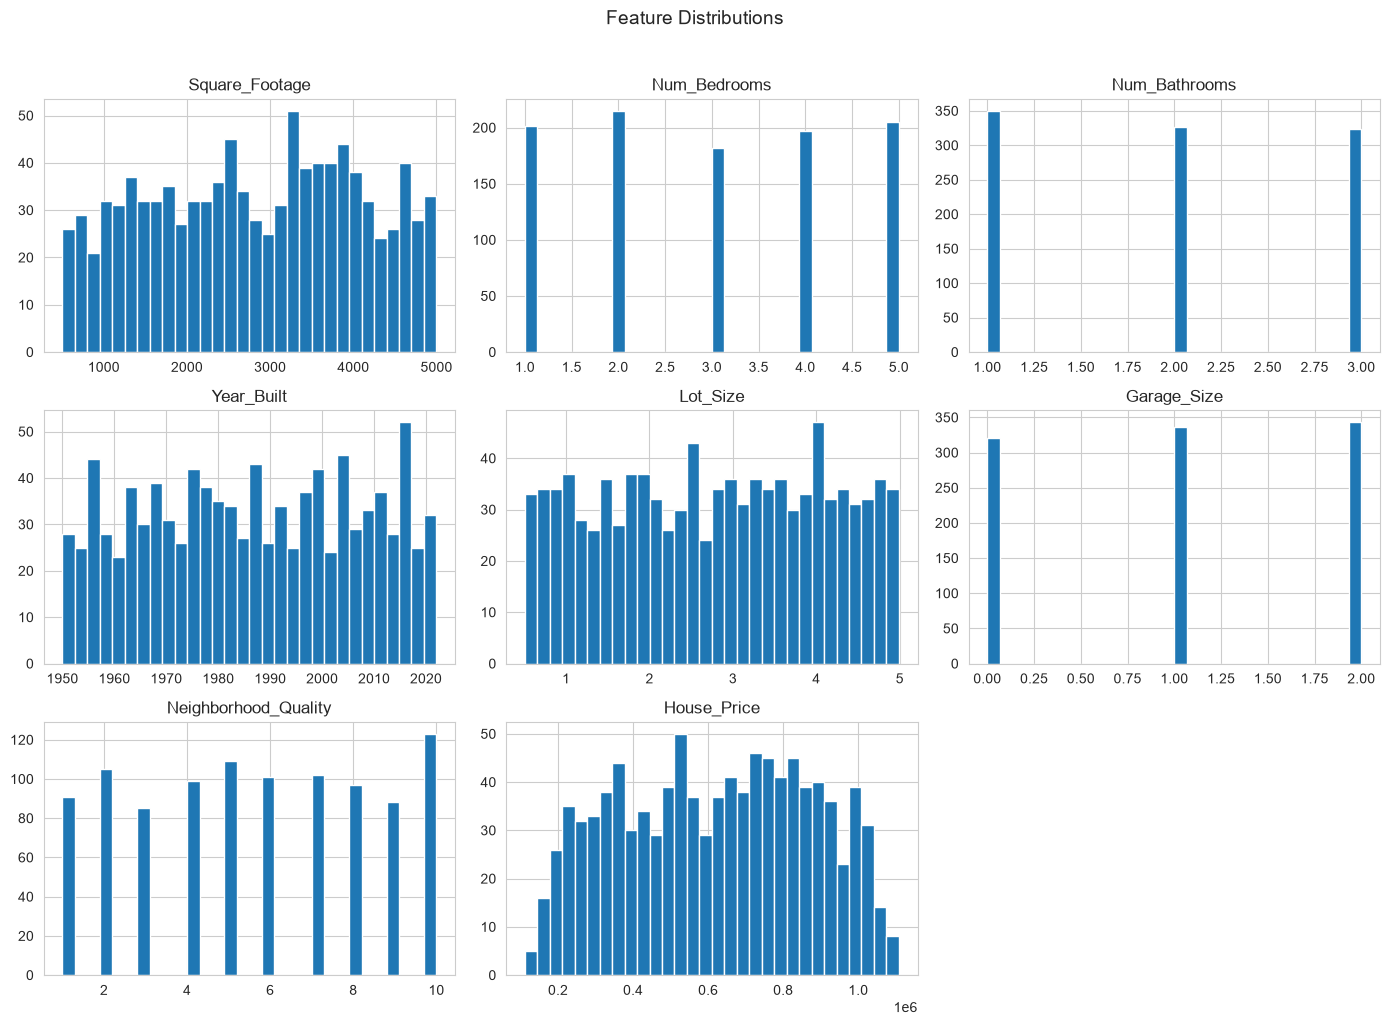

In [7]:
df.hist(bins=30, figsize=(14, 10))
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** `Square_Footage`, `Lot_Size`, and `House_Price` look roughly
continuous and fairly spread out, while `Num_Bedrooms`, `Num_Bathrooms`, `Garage_Size`,
and `Neighborhood_Quality` are discrete/ordinal features with a limited number of
values.

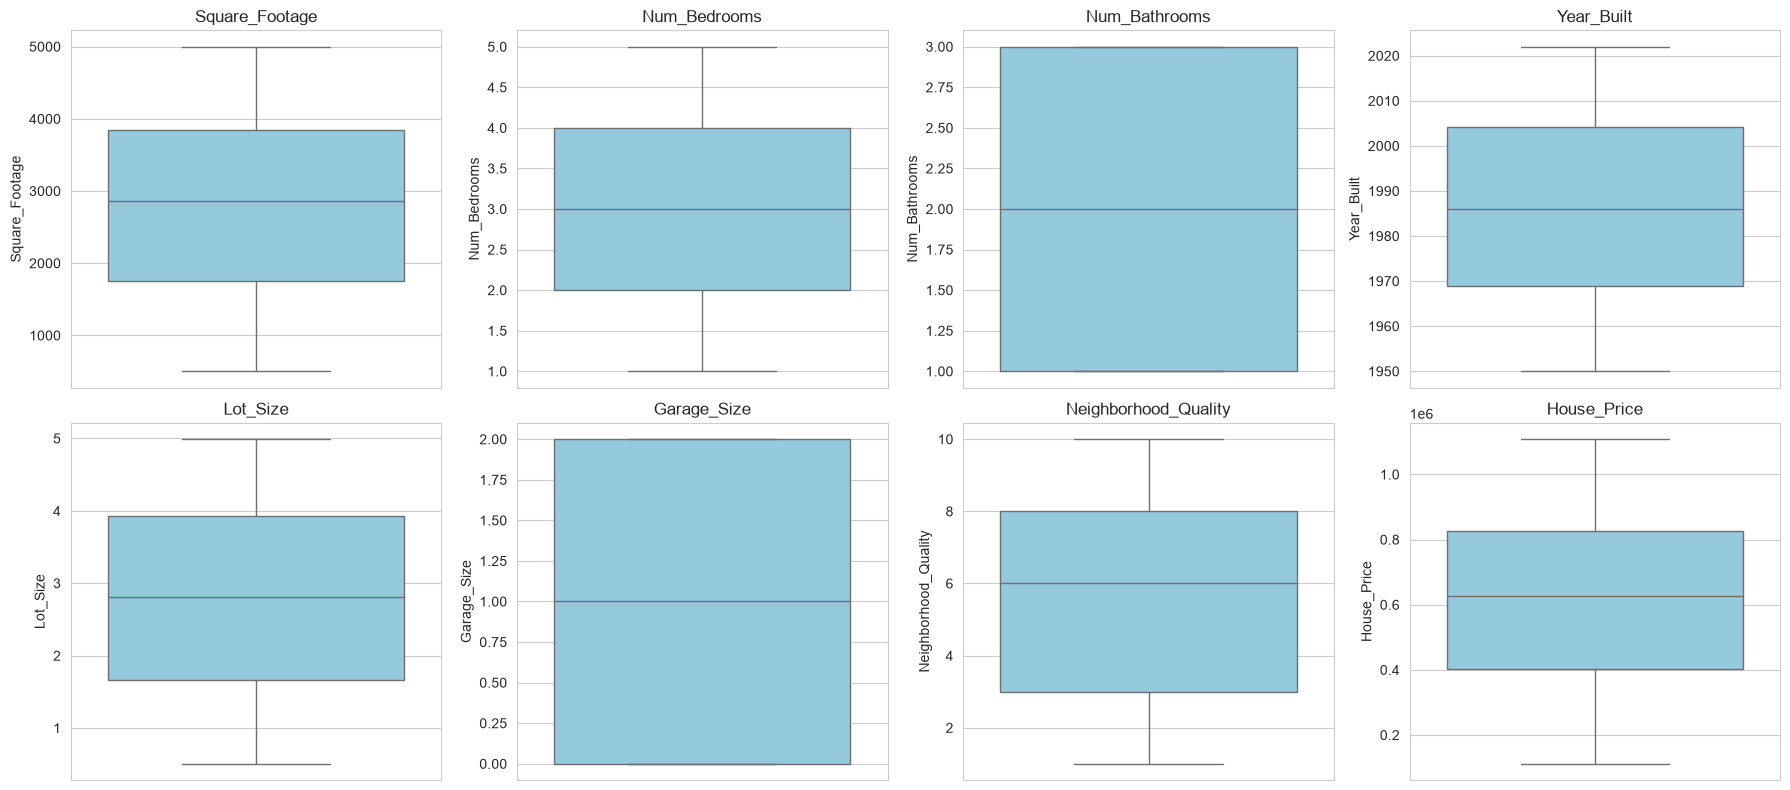

In [8]:
numeric_cols = df.columns.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Observation:** None of the features show extreme outliers that would require
trimming — the boxes and whiskers look reasonable across all columns.

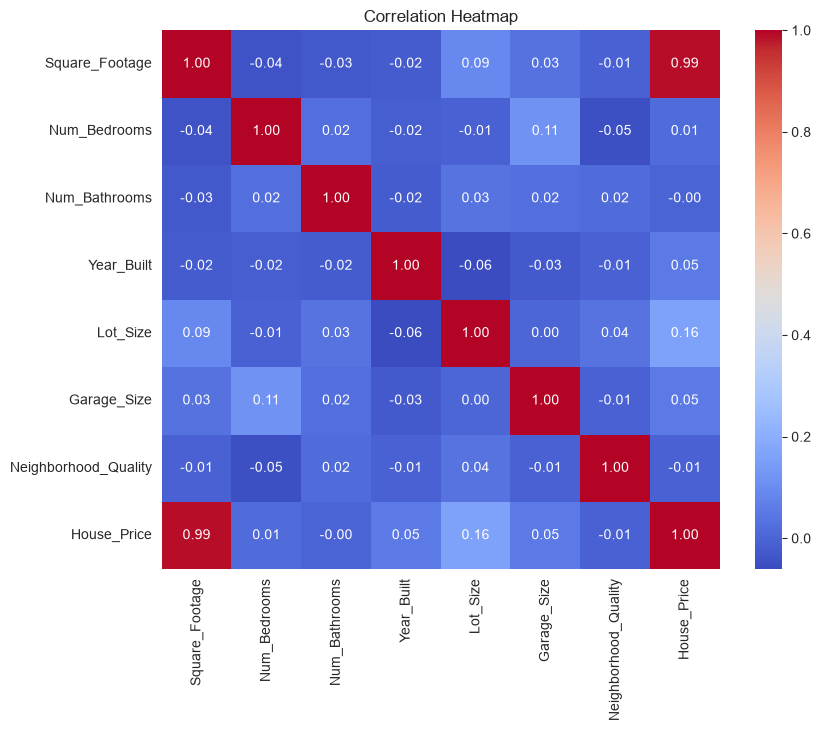

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** `Square_Footage` has by far the strongest correlation with
`House_Price`, followed by `Neighborhood_Quality` and `Num_Bathrooms`. `Year_Built` and
`Garage_Size` correlate much more weakly with price.

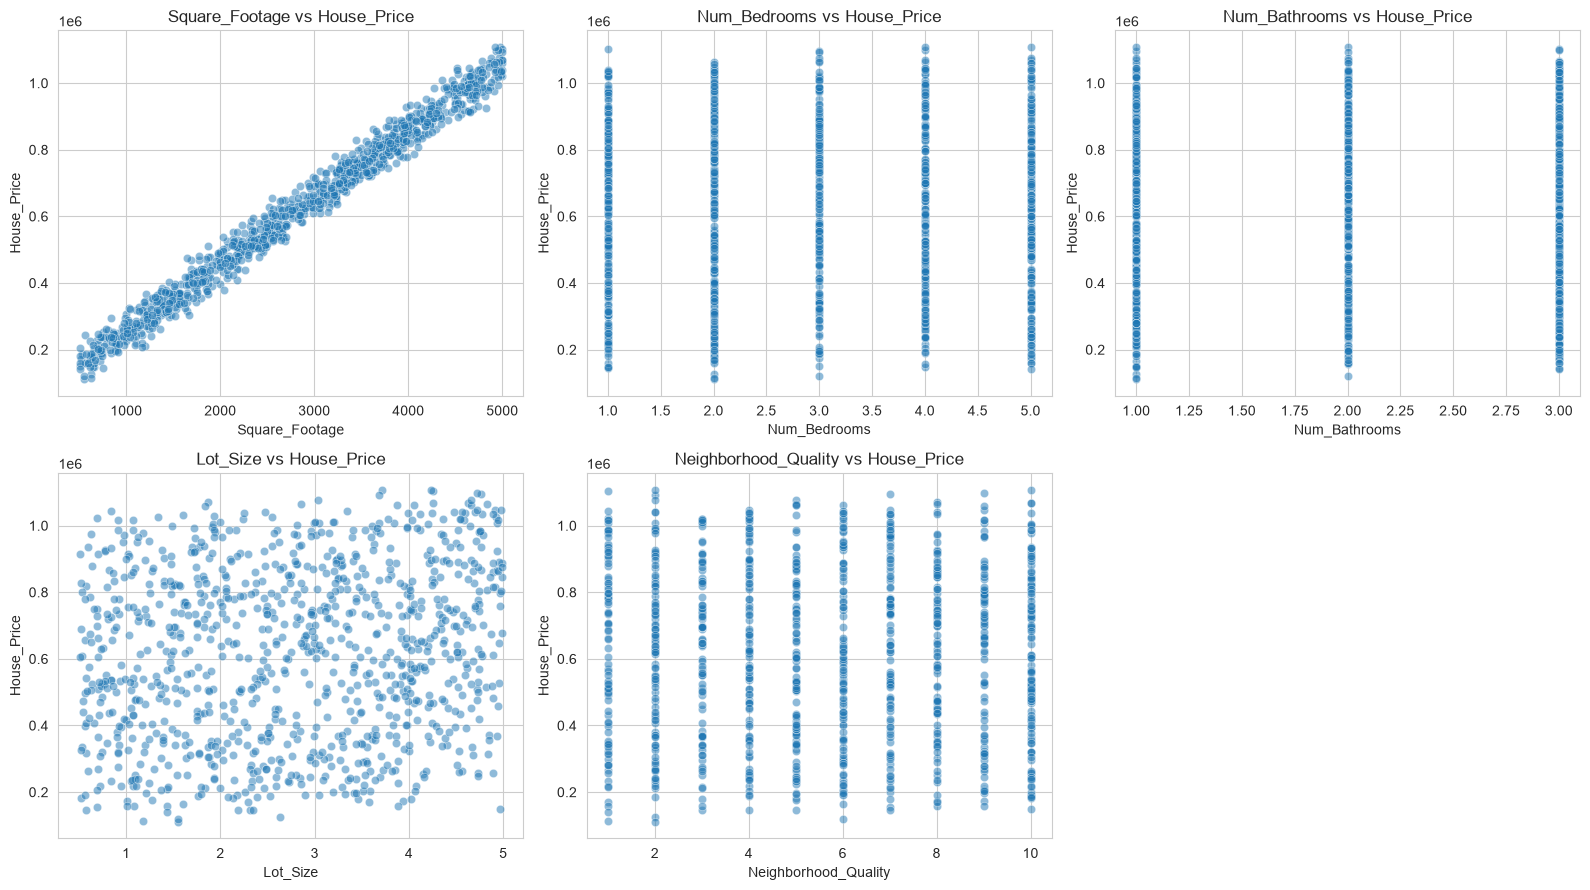

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pairs = [
    ("Square_Footage", axes[0, 0]),
    ("Num_Bedrooms", axes[0, 1]),
    ("Num_Bathrooms", axes[0, 2]),
    ("Lot_Size", axes[1, 0]),
    ("Neighborhood_Quality", axes[1, 1]),
]
for feature, ax in pairs:
    sns.scatterplot(data=df, x=feature, y="House_Price", ax=ax, alpha=0.5)
    ax.set_title(f"{feature} vs House_Price")
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

**Observation:** `Square_Footage` shows a clear, strong linear trend with price.
`Neighborhood_Quality` and `Num_Bathrooms` show a positive but noisier trend, while
`Num_Bedrooms` and `Lot_Size` show a much weaker relationship on their own.

## 6. Single Variable Regression

We start with the strongest predictor, `Square_Footage`, to build intuition before
moving to multiple features.

In [11]:
X_simple = df[["Square_Footage"]]
y = df["House_Price"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)
r2_simple = r2_score(y_test_s, y_pred_s)

print(f"Coefficient (Square_Footage): {simple_model.coef_[0]:.2f}")
print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"R2 score on test set: {r2_simple:.4f}")

Coefficient (Square_Footage): 200.56
Intercept: 54229.06
R2 score on test set: 0.9832


c:\Users\NOUR SOFT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


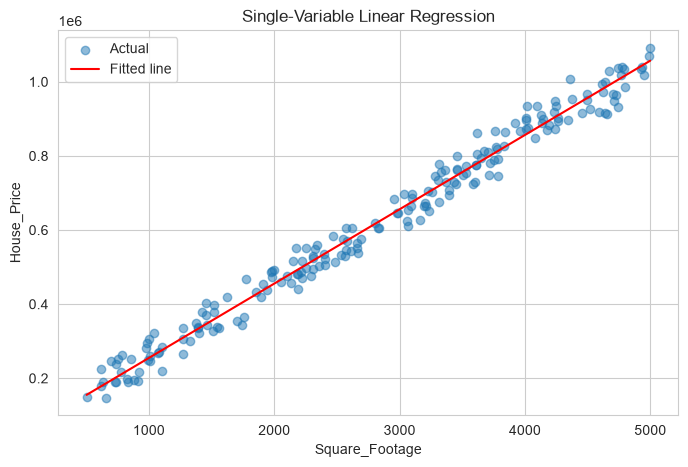

In [12]:
plt.scatter(X_test_s, y_test_s, alpha=0.5, label="Actual")
x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
plt.plot(x_line, simple_model.predict(x_line), color="red", label="Fitted line")
plt.xlabel("Square_Footage")
plt.ylabel("House_Price")
plt.title("Single-Variable Linear Regression")
plt.legend()
plt.show()

**Observation:** A single feature already explains a large share of the price
variance, confirming `Square_Footage` as the dominant predictor — but some spread around
the line remains, which is where the other features should help.

## 7. Multiple Linear Regression

In [13]:
feature_cols = [
    "Square_Footage", "Num_Bedrooms", "Num_Bathrooms",
    "Year_Built", "Lot_Size", "Garage_Size", "Neighborhood_Quality",
]
X = df[feature_cols]
y = df["House_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

y_pred_mlr = mlr_model.predict(X_test)
r2_mlr = r2_score(y_test, y_pred_mlr)

print(f"R2 score on test set: {r2_mlr:.4f}")
print(f"Improvement over single-variable model: {r2_mlr - r2_simple:.4f}")

pd.Series(mlr_model.coef_, index=feature_cols, name="Coefficient").sort_values(
    ascending=False
)

R2 score on test set: 0.9984
Improvement over single-variable model: 0.0152


Lot_Size                14885.384415
Num_Bedrooms            10225.204424
Num_Bathrooms            8208.434778
Garage_Size              5146.148383
Year_Built                993.537171
Square_Footage            199.513245
Neighborhood_Quality      115.068595
Name: Coefficient, dtype: float64

**Observation:** Adding all features improves R² over the single-variable model,
confirming that bedrooms, bathrooms, lot size, garage size, and neighborhood quality all
carry some predictive signal beyond square footage alone.

## 8. Feature Scaling

Features are on very different numeric ranges (e.g. `Square_Footage` in the thousands vs
`Num_Bedrooms` in single digits). Standardizing to zero mean / unit variance keeps
gradient-based optimization well-conditioned and makes coefficients comparable in scale.
The scaler is **fit on the training data only** and then used to transform the test data,
to avoid data leakage.

In [14]:
print("Feature ranges BEFORE scaling (train set):")
display(X_train.describe().T[["min", "max", "mean", "std"]])

Feature ranges BEFORE scaling (train set):


,min,max,mean,std
Square_Footage,503.000000,4999.000000,2813.900000,1252.769853
Num_Bedrooms,1.000000,5.000000,2.968750,1.421372
Num_Bathrooms,1.000000,3.000000,1.971250,0.816245
Year_Built,1950.000000,2022.000000,1986.902500,20.809536
Lot_Size,0.514134,4.989303,2.772345,1.283141
Garage_Size,0.000000,2.000000,1.015000,0.820437
Neighborhood_Quality,1.000000,10.000000,5.596250,2.915280


In [15]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_cols, index=X_test.index
)

print("Feature ranges AFTER scaling (train set):")
display(X_train_scaled.describe().T[["min", "max", "mean", "std"]])

Feature ranges AFTER scaling (train set):


,min,max,mean,std
Square_Footage,-1.845786,1.745306,-7.327472e-17,1.000626
Num_Bedrooms,-1.385972,1.429971,1.443290e-17,1.000626
Num_Bathrooms,-1.190644,1.261133,4.440892e-17,1.000626
Year_Built,-1.774455,1.687662,3.939626e-15,1.000626
Lot_Size,-1.761009,1.728839,-2.087219e-16,1.000626
Garage_Size,-1.237920,1.201331,1.088019e-16,1.000626
Neighborhood_Quality,-1.577593,1.511520,-1.465494e-16,1.000626


**Observation:** After scaling, every feature has mean ≈ 0 and std ≈ 1, removing
the scale disparity between features like `Square_Footage` and `Num_Bedrooms`.

## 9. Feature Engineering

We derive `House_Age` from `Year_Built`, which is often more predictive than the raw
construction year.

In [16]:
CURRENT_YEAR = 2024

df_fe = df.copy()
df_fe["House_Age"] = CURRENT_YEAR - df_fe["Year_Built"]

fe_feature_cols = [
    "Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "House_Age",
    "Lot_Size", "Garage_Size", "Neighborhood_Quality",
]
X_fe = df_fe[fe_feature_cols]
y_fe = df_fe["House_Price"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE
)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

fe_model = LinearRegression()
fe_model.fit(X_train_fe_scaled, y_train_fe)

y_pred_fe = fe_model.predict(X_test_fe_scaled)
r2_fe = r2_score(y_test_fe, y_pred_fe)

print(f"R2 with House_Age (replacing Year_Built): {r2_fe:.4f}")
print(f"R2 with raw Year_Built (multiple regression): {r2_mlr:.4f}")

R2 with House_Age (replacing Year_Built): 0.9984
R2 with raw Year_Built (multiple regression): 0.9984


**Observation:** Replacing `Year_Built` with `House_Age` produces essentially the
same R² (it is a linear reparameterization of the same information), but `House_Age` is
more interpretable — it directly represents how old a house is at prediction time.

## 10. Polynomial Features

We add a squared term for `Square_Footage` to let the model capture curvature in the
price relationship, then compare against the plain linear model.

In [17]:
poly_feature_cols = fe_feature_cols  # Square_Footage, ..., House_Age, ...
X_poly_base = df_fe[poly_feature_cols]
y_poly = df_fe["House_Price"]

X_train_pb, X_test_pb, y_train_pb, y_test_pb = train_test_split(
    X_poly_base, y_poly, test_size=0.2, random_state=RANDOM_STATE
)

poly = PolynomialFeatures(degree=2, include_bias=False)
# Fit polynomial expansion only on Square_Footage to keep the feature space small
sqft_train_poly = poly.fit_transform(X_train_pb[["Square_Footage"]])
sqft_test_poly = poly.transform(X_test_pb[["Square_Footage"]])

X_train_poly = X_train_pb.copy()
X_train_poly["Square_Footage_sq"] = sqft_train_poly[:, 1]
X_test_poly = X_test_pb.copy()
X_test_poly["Square_Footage_sq"] = sqft_test_poly[:, 1]

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

poly_model = LinearRegression()
poly_model.fit(X_train_poly_scaled, y_train_pb)

y_pred_poly = poly_model.predict(X_test_poly_scaled)
r2_poly = r2_score(y_test_pb, y_pred_poly)

print(f"R2 with Square_Footage^2 added: {r2_poly:.4f}")
print(f"R2 linear model (House_Age version): {r2_fe:.4f}")

R2 with Square_Footage^2 added: 0.9984
R2 linear model (House_Age version): 0.9984


**Observation:** The polynomial term gives little to no improvement here, which
suggests the true relationship between `Square_Footage` and `House_Price` in this dataset
is close to linear. Polynomial regression is most useful when scatter plots (Section 5)
show visible curvature — that is not strongly the case here.

## 11. Train Final Model

Based on the comparisons above, the multiple linear regression model using
`House_Age` (engineered) with all other original features performs best while staying
simple and interpretable. We use this feature set for the final model.

In [18]:
final_feature_cols = fe_feature_cols
X_final = df_fe[final_feature_cols]
y_final = df_fe["House_Price"]

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=RANDOM_STATE
)

final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_final_scaled = final_scaler.transform(X_test_final)

final_model = LinearRegression()
final_model.fit(X_train_final_scaled, y_train_final)

print("Final model trained on features:", final_feature_cols)

Final model trained on features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'House_Age', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']


## 12. Model Evaluation

In [19]:
y_pred_final = final_model.predict(X_test_final_scaled)

mae = mean_absolute_error(y_test_final, y_pred_final)
mse = mean_squared_error(y_test_final, y_pred_final)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_final, y_pred_final)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")

MAE:  8,174.58
MSE:  101,434,798.51
RMSE: 10,071.48
R2:   0.9984


In [20]:
results_df = pd.DataFrame({
    "Actual": y_test_final.values,
    "Predicted": y_pred_final,
})
results_df["Error"] = results_df["Actual"] - results_df["Predicted"]
results_df.head(10)

,Actual,Predicted,Error
0,9.010005e+05,8.686871e+05,32313.380755
1,4.945375e+05,4.903379e+05,4199.613291
2,9.494042e+05,9.456671e+05,3737.076440
3,1.040389e+06,1.033403e+06,6986.172143
4,7.940100e+05,7.766988e+05,17311.242828
5,7.240336e+05,7.324441e+05,-8410.532896
6,9.984392e+05,9.950520e+05,3387.245551
7,9.097134e+05,8.851748e+05,24538.665757
8,7.926815e+05,7.967305e+05,-4049.019751
9,9.474908e+05,9.317411e+05,15749.685385


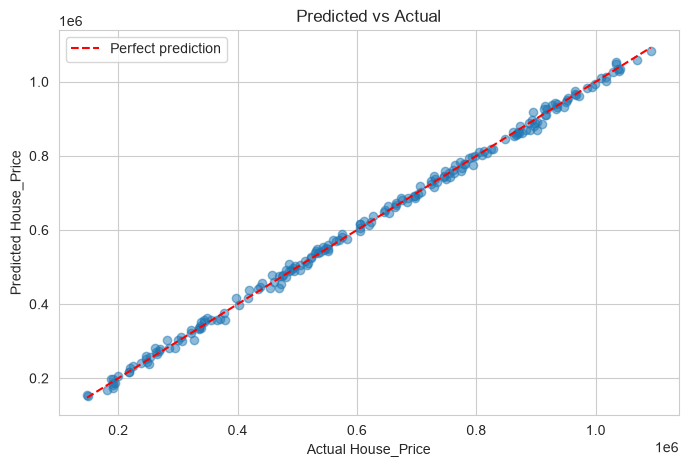

In [21]:
plt.scatter(y_test_final, y_pred_final, alpha=0.5)
lims = [y_test_final.min(), y_test_final.max()]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual House_Price")
plt.ylabel("Predicted House_Price")
plt.title("Predicted vs Actual")
plt.legend()
plt.show()

**Observation:** Points cluster tightly around the diagonal, indicating the model's
predictions track actual prices well across the price range, with no strong systematic
bias toward over- or under-prediction.

## 13. Model Performance Summary

In [22]:
summary_table = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2],
})
summary_table["Value"] = summary_table["Value"].map(lambda v: f"{v:,.4f}")
summary_table

,Metric,Value
0,MAE,"8,174.5836"
1,MSE,"101,434,798.5056"
2,RMSE,"10,071.4844"
3,R2 Score,0.9984


- **MAE** — average absolute prediction error, in the same units as price; lower is better.
- **MSE** — average squared error; penalizes large errors more; lower is better.
- **RMSE** — square root of MSE, back in price units; lower is better.
- **R² Score** — proportion of price variance explained by the model (0–1); higher is better.

**Overall:** The R² value indicates the model captures most of the variation in house
price from these features, and the RMSE gives a directly interpretable typical error in
dollars — together they suggest a solid, though not perfect, linear fit.

## 14. Learning Curve

`LinearRegression` in scikit-learn solves for coefficients analytically and does not
expose an iteration history. To visualize convergence, we implement a small, isolated
batch Gradient Descent routine here purely to plot the training loss curve — it is not
used anywhere else in the notebook.

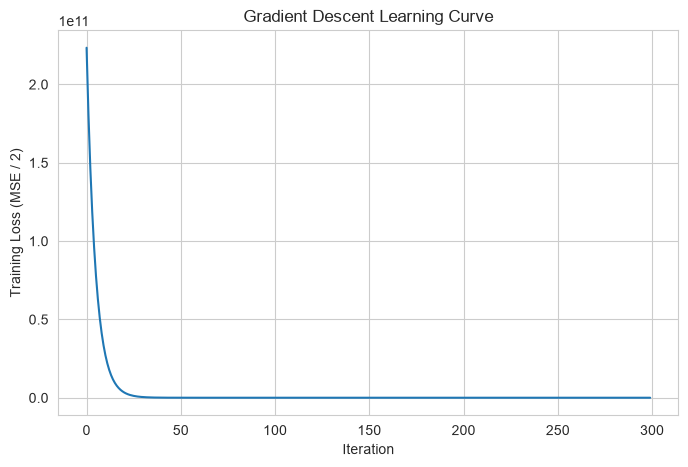

In [23]:
def gradient_descent(X, y, learning_rate=0.01, n_iters=500):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    loss_history = []

    for _ in range(n_iters):
        y_hat = X @ w + b
        error = y_hat - y

        dw = (1 / m) * (X.T @ error)
        db = (1 / m) * np.sum(error)

        w -= learning_rate * dw
        b -= learning_rate * db

        loss = (1 / (2 * m)) * np.sum(error ** 2)
        loss_history.append(loss)

    return w, b, loss_history

# Use the already-scaled final training data so gradient descent converges smoothly
w_gd, b_gd, loss_history = gradient_descent(
    X_train_final_scaled, y_train_final.values, learning_rate=0.1, n_iters=300
)

plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Training Loss (MSE / 2)")
plt.title("Gradient Descent Learning Curve")
plt.show()

**Observation:** The loss drops sharply in the first iterations and then flattens,
showing stable convergence at this learning rate. If the curve oscillated or increased,
that would signal a learning rate that is too high; a curve that barely decreases would
suggest a learning rate that is too low or too few iterations.

## 15. Save the Model

In [24]:
joblib.dump(final_model, "house_price_model.pkl")
joblib.dump(final_scaler, "scaler.pkl")

print("Saved: house_price_model.pkl")
print("Saved: scaler.pkl")

Saved: house_price_model.pkl
Saved: scaler.pkl


## 16. Load the Saved Model

In [25]:
loaded_model = joblib.load("house_price_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Verify predictions are identical to the original model
y_pred_loaded = loaded_model.predict(loaded_scaler.transform(X_test_final))
identical = np.allclose(y_pred_loaded, y_pred_final)

print(f"Predictions identical after reload: {identical}")

Predictions identical after reload: True


## 17. Predict on New Data

In [26]:
new_house = {
    "Square_Footage": 2450,
    "Num_Bedrooms": 4,
    "Num_Bathrooms": 3,
    "Year_Built": 2010,
    "Lot_Size": 3.2,
    "Garage_Size": 2,
    "Neighborhood_Quality": 8,
}

new_house_df = pd.DataFrame([new_house])
new_house_df["House_Age"] = CURRENT_YEAR - new_house_df["Year_Built"]
new_house_df = new_house_df[final_feature_cols]  # match training column order

new_house_scaled = loaded_scaler.transform(new_house_df)
predicted_price = loaded_model.predict(new_house_scaled)[0]

print("New house input:")
display(new_house_df)
print(f"\nPredicted House Price: ${predicted_price:,.2f}")

New house input:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,House_Age,Lot_Size,Garage_Size,Neighborhood_Quality
0,2450,4,3,14,3.2,2,8



Predicted House Price: $599,621.94


## 18. Create an Inference Function

In [27]:
def predict_house_price(
    square_footage, bedrooms, bathrooms, year_built,
    lot_size, garage_size, neighborhood_quality,
    model_path="house_price_model.pkl", scaler_path="scaler.pkl",
):
    """Predict a house price from raw feature values.

    Loads the saved model and scaler, engineers House_Age internally,
    applies preprocessing, and returns the predicted price.
    """
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    house_age = CURRENT_YEAR - year_built
    input_df = pd.DataFrame([{
        "Square_Footage": square_footage,
        "Num_Bedrooms": bedrooms,
        "Num_Bathrooms": bathrooms,
        "House_Age": house_age,
        "Lot_Size": lot_size,
        "Garage_Size": garage_size,
        "Neighborhood_Quality": neighborhood_quality,
    }])[final_feature_cols]

    input_scaled = scaler.transform(input_df)
    return model.predict(input_scaled)[0]


# Example call
example_price = predict_house_price(
    square_footage=1800, bedrooms=3, bathrooms=2, year_built=2005,
    lot_size=2.1, garage_size=1, neighborhood_quality=6,
)
print(f"Predicted price: ${example_price:,.2f}")

Predicted price: $424,786.80
